# CSC 411 Final Project

Our dataset is...

The target variable is...

Our purpose for using this dataset is...

In [ ]:
import os

# Folder containing HAM10000_metadata.csv, hmnist_28_28_RGB.csv and the image folders.
# Leave empty to download the dataset from Kaggle with kagglehub.
DATA_DIR = os.environ.get("HAM10000_DATA_DIR", "")

# Download the Data

In [2]:
!nvidia-smi --list-gpus

GPU 0: Tesla T4 (UUID: GPU-c4cb6bd1-2e0c-bc67-5ee3-0ba597936005)


In [3]:
# Kaggle Utilities
import kagglehub

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os
from PIL import Image
import shutil
from shutil import copyfile
from sklearn.model_selection import train_test_split
from mlxtend.evaluate import confusion_matrix
from tqdm import tqdm

print("Import Success!")

Import Success!


In [5]:
# Download latest version
path = DATA_DIR or kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)


100%|██████████| 5.20G/5.20G [03:55<00:00, 23.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [6]:
# List all files in the dataset directory
print(os.listdir(path))

['hmnist_8_8_RGB.csv', 'ham10000_images_part_1', 'HAM10000_images_part_1', 'hmnist_8_8_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_28_28_L.csv', 'ham10000_images_part_2', 'HAM10000_images_part_2', 'HAM10000_metadata.csv']


In [7]:
# Load metadata file
metadata_path = os.path.join(path, 'HAM10000_metadata.csv')
metadata = pd.read_csv(metadata_path)
metadata

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [8]:
# Paths to both sets of directories
dir1_uppercase = os.path.join(path, 'HAM10000_images_part_1')
dir1_lowercase = os.path.join(path, 'ham10000_images_part_1')

# Compare file names
files_upper = set(os.listdir(dir1_uppercase))
files_lower = set(os.listdir(dir1_lowercase))

# Check for differences
print("Files in uppercase directory but not in lowercase:", files_upper - files_lower)
print("Files in lowercase directory but not in uppercase:", files_lower - files_upper)

# If both sets are identical, they are duplicates
if files_upper == files_lower:
    print("The directories are duplicates.")
else:
    print("The directories are not identical.")

Files in uppercase directory but not in lowercase: set()
Files in lowercase directory but not in uppercase: set()
The directories are duplicates.


In [9]:
# Paths to the directories containing images
image_part1_path = os.path.join(path, 'HAM10000_images_part_1')
image_part2_path = os.path.join(path, 'HAM10000_images_part_2')

print("Images in part 1:", os.listdir(image_part1_path)[:5])
print("Images in part 2:", os.listdir(image_part2_path)[:5])

Images in part 1: ['ISIC_0029206.jpg', 'ISIC_0024695.jpg', 'ISIC_0024900.jpg', 'ISIC_0028457.jpg', 'ISIC_0029139.jpg']
Images in part 2: ['ISIC_0031766.jpg', 'ISIC_0032802.jpg', 'ISIC_0033464.jpg', 'ISIC_0030339.jpg', 'ISIC_0034081.jpg']


In [10]:
# Path to the combined directory
combined_images_dir = os.path.join(path, 'combined_images')
os.makedirs(combined_images_dir, exist_ok=True)

# Copy images from both directories into one
for part_path in [image_part1_path, image_part2_path]:
    for file_name in os.listdir(part_path):
        src = os.path.join(part_path, file_name)
        dest = os.path.join(combined_images_dir, file_name)
        if os.path.isfile(src):  # Ensure it's a file
            copyfile(src, dest)

print(f"Combined images are in: {combined_images_dir}")
print("Sample combined images:", os.listdir(combined_images_dir)[:5])

Combined images are in: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2/combined_images
Sample combined images: ['ISIC_0031766.jpg', 'ISIC_0029206.jpg', 'ISIC_0024695.jpg', 'ISIC_0024900.jpg', 'ISIC_0032802.jpg']


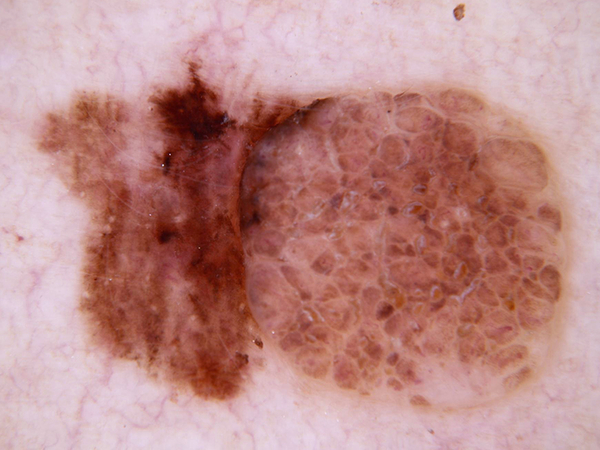

In [11]:
# Example: Load a sample image
sample_image_path = os.path.join(combined_images_dir, 'ISIC_0028543.jpg')  # Replace with an actual image
image = Image.open(sample_image_path)
display(image)

## Checking Image Size

In [12]:
# List all image file paths
image_paths = [os.path.join(combined_images_dir, fname) for fname in os.listdir(combined_images_dir) if fname.endswith(('.jpg', '.png'))]

# Check sizes of all images
image_sizes = []
for image_path in image_paths:
    with Image.open(image_path) as img:
        image_sizes.append(img.size)  # img.size returns (width, height)

# Display unique image sizes
unique_sizes = set(image_sizes)
print("Unique image sizes:", unique_sizes)


Unique image sizes: {(600, 450)}


## Plot Sample Images from each Class

In [13]:
# Plotting function
def plots(ims, figsize=(12, 6), rows=1, interp=False, titles=None):
    if isinstance(ims[0], np.ndarray):
        ims = np.array(ims).astype(np.uint8)
        if ims.shape[-1] != 3:
            ims = ims.transpose((0, 2, 3, 1))  # Handle channel-first format
    f = plt.figure(figsize=figsize)
    cols = len(ims) // rows if len(ims) % rows == 0 else len(ims) // rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i + 1)
        sp.axis('off')
        if titles is not None:
            sp.set_title(str(titles[i]), fontsize=10)
        plt.imshow(ims[i], interpolation=None if interp else 'none')
    plt.tight_layout()

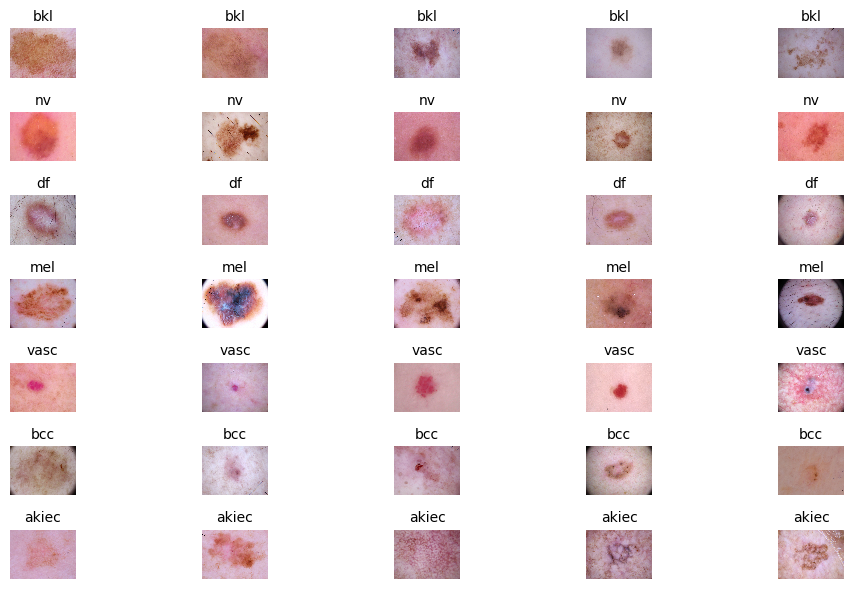

In [14]:
# Get unique lesion classes
classes = metadata['dx'].unique()  # Unique lesion classes
class_images = {cls: [] for cls in classes}  # Dictionary to store images by class

# Load a few images for each class
for cls in classes:
    cls_data = metadata[metadata['dx'] == cls]
    sampled_images = cls_data.sample(n=5, random_state=42)  # Randomly sample 5 images
    for image_id in sampled_images['image_id']:
        # Construct the full path to the image
        image_path = os.path.join(combined_images_dir, f"{image_id}.jpg")
        if os.path.exists(image_path):  # Check if the file exists
            img = Image.open(image_path)
            class_images[cls].append(np.array(img))
        else:
            print(f"Image not found: {image_path}")  # Debugging message

# Combine images and titles for plotting
all_images = []
all_titles = []
for cls, images in class_images.items():
    all_images.extend(images)
    all_titles.extend([cls] * len(images))

# Plot images, grouped by class
plots(all_images, titles=all_titles, rows=len(classes))
plt.tight_layout()
plt.savefig('class_images.png')
plt.show()

## Exploratory Data Analysis

In [15]:
# Check missing values
metadata.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


### Visualization of metadata

In [16]:
metadata['age'].describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


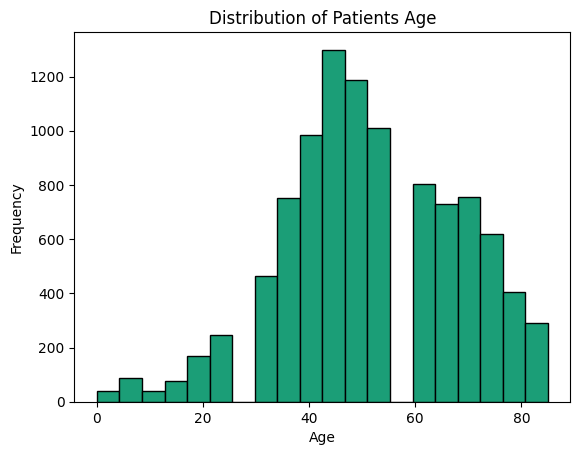

In [17]:
# age distribution - histogram
metadata['age'].plot(kind='hist', bins=20, color=sns.color_palette('Dark2')[0], edgecolor='black')

plt.title('Distribution of Patients Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('age_distribution.png')
plt.show()

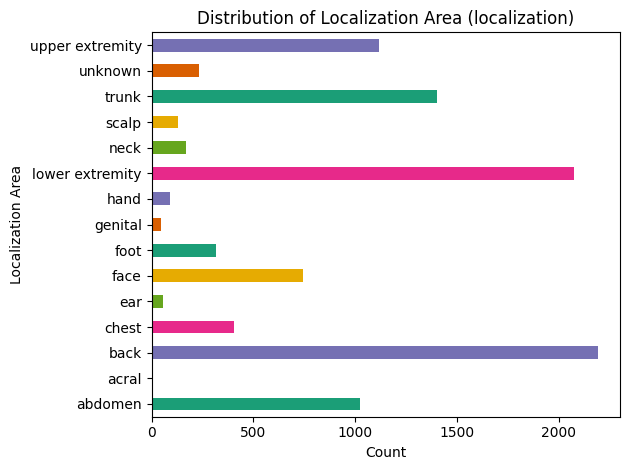

In [18]:
# localization distribution
metadata.groupby('localization').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))

plt.title('Distribution of Localization Area (localization)')
plt.xlabel('Count')
plt.ylabel('Localization Area')

plt.tight_layout()
plt.savefig('localization_distribution.png')

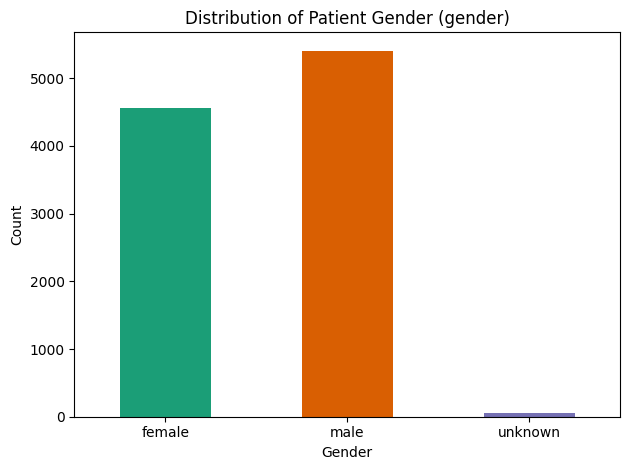

In [19]:
# gender distribution
metadata.groupby('sex').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))

plt.title('Distribution of Patient Gender (gender)')
plt.xlabel('Gender', )
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.show()

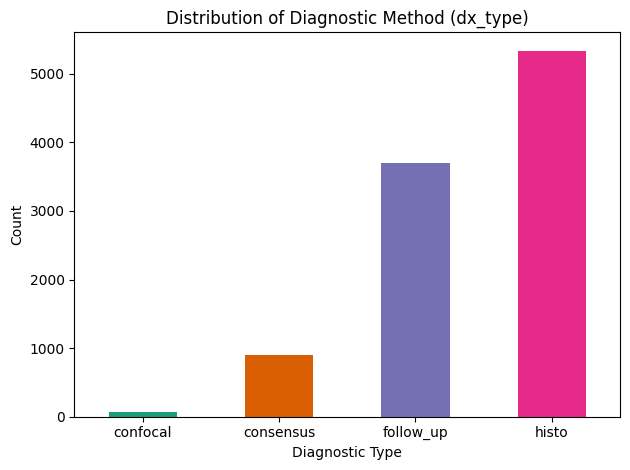

In [20]:
# dx_type distribution
metadata.groupby('dx_type').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))

plt.title('Distribution of Diagnostic Method (dx_type)')
plt.xlabel('Diagnostic Type')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('dx_type_distribution.png')
plt.show()

### Target Variable

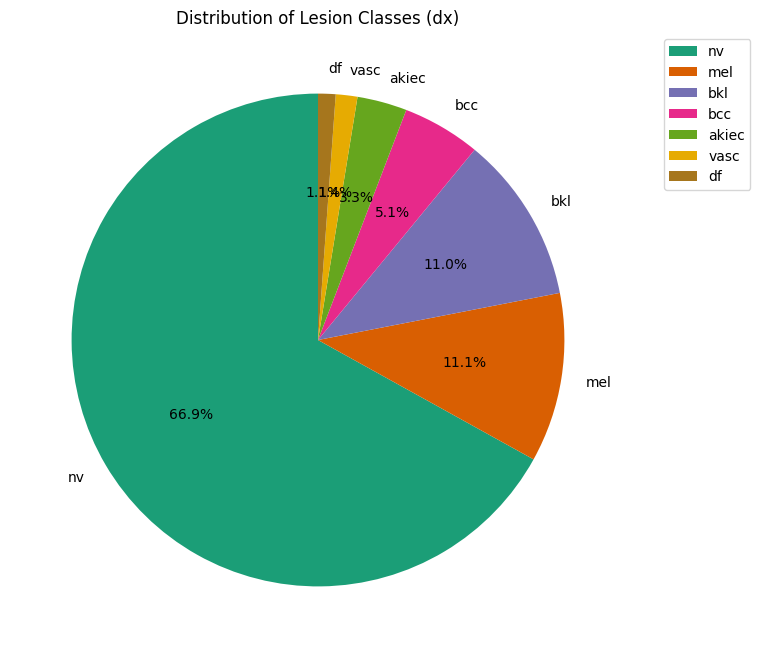

In [21]:
# dx distribution - pie chart
# Plot the distribution of 'dx' as a pie chart
metadata['dx'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',  # Show percentages with one decimal place
    colors=sns.color_palette('Dark2'),
    figsize=(8, 8),
    startangle=90  # Rotate the pie chart for better visualization
)

plt.title('Distribution of Lesion Classes (dx)')
plt.ylabel('')  # Remove the y-label for better aesthetics
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('dx_distribution_pie.png')
plt.show()

In [22]:
# check for duplicate image_id values
duplicate_image_ids = metadata[metadata.duplicated(subset=['image_id'], keep=False)]['image_id'].unique()

#print the duplicate image_ids
print("Duplicate image_ids:", duplicate_image_ids)

#get counts of each image_id
image_id_counts = metadata['image_id'].value_counts()
print(image_id_counts)

#filter for image_ids with count > 1 (duplicates)
duplicate_image_ids = image_id_counts[image_id_counts > 1].index.tolist()
print("Duplicate image_ids:", duplicate_image_ids)

# Remove duplicates, keeping the first occurrence
metadata_no_duplicates = metadata.drop_duplicates(subset=['image_id'], keep='first')
print(metadata_no_duplicates.head())

Duplicate image_ids: []
image_id
ISIC_0032258    1
ISIC_0027419    1
ISIC_0025030    1
ISIC_0026769    1
ISIC_0025661    1
               ..
ISIC_0027815    1
ISIC_0024324    1
ISIC_0029559    1
ISIC_0030661    1
ISIC_0027053    1
Name: count, Length: 10015, dtype: int64
Duplicate image_ids: []
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [23]:
image_id_counts = metadata_no_duplicates['image_id'].value_counts()

if duplicate_image_ids:
  print("Duplicate image_ids found:", duplicate_image_ids)
else:
  print("No duplicates found.")

No duplicates found.


## Data Preprocessing for Image Data - Only used by CNN & Efficienet

## Split Data & Map images to image_id in metadata

In [24]:
# Split dataset and organize files
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [25]:
def move_files(df, target_dir):
    """Moves files into class-specific directories."""
    for _, row in df.iterrows():
        image_id, label = row['image_id'], row['dx']
        src = os.path.join(combined_images_dir, f"{image_id}.jpg")
        class_dir = os.path.join(target_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(class_dir, f"{image_id}.jpg"))

In [26]:
# Split data into train and test sets
train_df, test_df = train_test_split(metadata, test_size=0.2, random_state=42)

move_files(train_df, train_dir)
move_files(test_df, test_dir)

### Create validation set, Normalization and Resize Images

In [27]:
# Define ImageDataGenerator for train and test
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

# Image size and batch size
image_size = (224, 224)
batch_size = 32

# Load train and validation data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training subset
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation subset
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # No shuffling for evaluation
)

print("Data generators created successfully!")


Found 7214 images belonging to 7 classes.
Found 798 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
Data generators created successfully!


In [28]:
# Check class indices
print("Class indices:", train_generator.class_indices)

# Load a batch of images and labels
images, labels = next(train_generator)
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)


Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Batch shape: (32, 224, 224, 3)
Labels shape: (32, 7)


In [29]:
# Check class imbalance again
class_counts = train_generator.classes
# Use np.unique with return_counts=True to get class counts
unique_classes, counts = np.unique(class_counts, return_counts=True)

# Print the class counts
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} samples")

# Alternatively, to get the total number of samples:
total_samples = len(class_counts)
print(f"Total samples: {total_samples}")

Class 0: 233 samples
Class 1: 379 samples
Class 2: 784 samples
Class 3: 79 samples
Class 4: 799 samples
Class 5: 4831 samples
Class 6: 109 samples
Total samples: 7214


### Data Augmentation to handle class imbalance


In [30]:
def augment_class(class_name, source_dir, target_dir, num_augmentations):
    os.makedirs(target_dir, exist_ok=True)
    datagen = ImageDataGenerator(rotation_range=20,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)

    for img_name in os.listdir(source_dir):
        img_path = os.path.join(source_dir, img_name)
        with Image.open(img_path) as img:
            img_array = np.expand_dims(np.array(img), axis=0)
            gen = datagen.flow(img_array, batch_size=1, save_to_dir=target_dir,
                               save_prefix=class_name, save_format='jpg')
            for _ in range(num_augmentations):
                next(gen)

In [33]:
class_sizes = [len(os.listdir(os.path.join(train_dir, cls))) for cls in os.listdir(train_dir)]
target_size = int(np.median(class_sizes))
print(f"Target size: {target_size}")
print(f"New total train set size: {target_size * 7}")

Target size: 421
New total train set size: 2947


### Strategy: Upsample minority classes and downsample majority class to target size

In [ ]:
for cls in os.listdir(train_dir):
    source_dir = os.path.join(train_dir, cls)
    current_count = len(os.listdir(source_dir))
    if current_count < target_size:
        augment_class(cls, source_dir, os.path.join(train_dir, f"augmented_{cls}"),
                      target_size - current_count)

In [ ]:
# Check class distribution
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in os.listdir(train_dir)}
print("Balanced Class Distribution:", class_counts)

In [ ]:
# print size of train, val and test set again

# Function to calculate total number of files in a directory (including subdirectories)
def get_total_images(directory):
    total_images = 0
    for class_dir in os.listdir(directory):  # Iterate over each class directory
        class_path = os.path.join(directory, class_dir)
        if os.path.isdir(class_path):  # Check if it's a directory
            total_images += len(os.listdir(class_path))
    return total_images

# Print total size of each set
print("Train set size:", get_total_images(train_dir))
print("Validation set size:", get_total_images(validation_generator.directory))
print("Test set size:", get_total_images(test_dir))


In [ ]:
421*7

## Preprocessing for Logistic Regression

In [ ]:
# Load csv file
logregRGBcsv_path = os.path.join(path, 'hmnist_28_28_RGB.csv')
logregRGBcsv = pd.read_csv(logregRGBcsv_path)
logregRGBcsv

## Normalization for Logistic Regression

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# load the dataset
logregRGBcsv_path = os.path.join(path, 'hmnist_28_28_RGB.csv')
logregRGBcsv = pd.read_csv(logregRGBcsv_path)

In [ ]:
#separate features and target variable
X = logregRGBcsv.iloc[:, 1:] # features (pixel values)
y = logregRGBcsv.iloc[:, 0]  # target variable (label)

In [ ]:
#normalize the features
#create a MinMaxScaler object
scaler = MinMaxScaler()

#fit the scaler to the features and transform them
X_normalized = scaler.fit_transform(X)

# convert the normalized features back to a DataFrame (optional)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)
normalized_dataset = pd.concat([y, X_normalized], axis=1)

### Visualize the Normalized Data for Logistic Regression

In [ ]:
# Assuming X_normalized is your normalized feature data (NumPy array)
X_normalized_array = X_normalized.values
image_data = X_normalized_array.reshape(-1, 28, 28, 3)

In [ ]:
# Display a single image (e.g., the first image)
plt.imshow(image_data[0])
plt.title("Processed Image")
plt.axis('off') # Hide axis ticks
plt.show()

# Display multiple images in a grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(8, 6)) # Adjust nrows, ncols as needed

for i, ax in enumerate(axes.flat):
    ax.imshow(image_data[i])
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Multi-class logistic regression

approach 1:

or approach 2

In [ ]:
from tensorflow.keras.layers import Normalization
#extract features (X) and target (y) from the dataframe
X = logregRGBcsv.drop('label', axis=1)
y = logregRGBcsv['label']

#split the data into training and testing sets
from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multi_feature = np.array(train_features[['pixel0000', 'pixel0001']]) #replaced with the actual feature column names

multi_feature_normalizer = Normalization(input_shape=[2,], axis=None)
multi_feature_normalizer.adapt(multi_feature)

In [ ]:
multi_feature_model = tf.keras.Sequential([
    multi_feature_normalizer
])

nb_classes = 2
number_of_features = 1 #X_train.shape[1]
#train_lables_in_classes = tf.keras.utils.to_categorical( train_labels,nb_classes )

#determine the actual number of classes in 'train_labels'
nb_classes = len(np.unique(train_labels))

#convert labels to categorical using the correct number of classes
train_lables_in_classes = tf.keras.utils.to_categorical( train_labels,nb_classes )

In [ ]:
multi_feature_model.summary()

In [ ]:
multi_feature_model.add(Dense(nb_classes,activation = 'sigmoid',input_dim = number_of_features))
multi_feature_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#one_feature_model.compile(optimizer='adam', loss='log_loss', metrics=['accuracy'])

multi_feature_model.summary()

In [ ]:
history = multi_feature_model.fit(
    train_features[['pixel0000', 'pixel0001']], train_lables_in_classes,
    epochs=40, batch_size=4,
    # suppress logging
    verbose=1,
    # Calculate validation results on 20% of the training data
    validation_split = 0.2)

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0.25, 1.5])
  plt.xlabel('Epoch')
  plt.ylabel('Error [DX]')
  plt.legend()
  plt.grid(True)

In [ ]:
plot_loss(history)

In [ ]:
test_results = {}
test_lables_in_classes = tf.keras.utils.to_categorical( test_labels,nb_classes )

test_results['FEATURE_model'] = multi_feature_model.evaluate(
    test_features[['pixel0000', 'pixel0001']],
    test_lables_in_classes , verbose=1)

In [ ]:
#import the confusion_matric function from sklearn.metrics

from sklearn.metrics import confusion_matrix

test_pred = multi_feature_model.predict(test_features[['pixel0000', 'pixel0001']])
preds_classes = np.argmax(test_pred, axis=-1)
preds_classes
cm = confusion_matrix(test_labels, preds_classes)

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                        normalize=False,
                        title='Confusion matrix',
                        cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
cm_plot_labels = target.index
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')